In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
df = pd.read_csv("/content/Day15_Executive_Hotel_Booking_EDA_Dataset.csv")
print(df.shape)
df.head()

(25180, 35)


,Booking_ID,Hotel_Type,Hotel_Location,Booking_Date,Arrival_Date,Lead_Time_Days,Weekend_Nights,Weekday_Nights,Adults,Children,...,Meal_Type,Total_Nights,ADR,Required_Car_Parking_Spaces,Total_Special_Requests,Satisfaction_Score,Reservation_Status,Is_Canceled,Reservation_Status_Date,Estimated_Revenue
0,HTL024548,City Hotel,London,2024-07-29,2025-07-04,340,2,2,2,0.0,...,HB,4,178.66,0,1,4.37,No-Show,1,2025-07-07,714.65
1,HTL019878,City Hotel,London,2024-05-28,2025-02-08,256,1,2,2,2.0,...,Undefined,3,125.81,0,0,3.63,Canceled,1,2025-02-09,377.43
2,HTL017377,City Hotel,Lisbon,2024-05-10,2024-06-20,41,1,1,4,0.0,...,FB,2,148.03,0,0,3.70,Check-Out,0,2024-06-20,296.06
3,HTL003352,City Hotel,Lisbon,2024-03-15,2024-04-07,23,0,2,2,0.0,...,HB,2,166.82,0,3,3.18,Check-Out,0,2024-04-08,333.63
4,HTL012521,City Hotel,London,2024-08-21,2025-05-30,282,0,3,4,0.0,...,HB,3,76.83,0,1,3.79,Check-Out,0,2025-06-01,230.50


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25180 entries, 0 to 25179
Data columns (total 35 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Booking_ID                   25180 non-null  object 
 1   Hotel_Type                   25180 non-null  object 
 2   Hotel_Location               25074 non-null  object 
 3   Booking_Date                 25180 non-null  object 
 4   Arrival_Date                 25180 non-null  object 
 5   Lead_Time_Days               25180 non-null  int64  
 6   Weekend_Nights               25180 non-null  int64  
 7   Weekday_Nights               25180 non-null  int64  
 8   Adults                       25180 non-null  int64  
 9   Children                     25059 non-null  float64
 10  Babies                       25180 non-null  int64  
 11  Country                      24714 non-null  object 
 12  Market_Segment               25180 non-null  object 
 13  Distribution_Cha

In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Lead_Time_Days,25180.0,182.200556,105.604452,0.00,91.00,182.000,273.0000,920.00
Weekend_Nights,25180.0,1.240429,1.063802,0.00,0.00,1.000,2.0000,3.00
Weekday_Nights,25180.0,2.451072,2.031003,0.00,1.00,2.000,4.0000,13.00
Adults,25180.0,2.198967,0.662379,1.00,2.00,2.000,2.0000,7.00
Children,25059.0,0.372122,0.657811,0.00,0.00,0.000,1.0000,6.00
Babies,25180.0,0.043050,0.225057,0.00,0.00,0.000,0.0000,2.00
Is_Repeated_Guest,25180.0,0.172597,0.377906,0.00,0.00,0.000,0.0000,1.00
Previous_Cancellations,25180.0,0.038642,0.251403,0.00,0.00,0.000,0.0000,3.00
Previous_Bookings,25180.0,1.117037,2.829046,0.00,0.00,0.000,0.0000,12.00
Booking_Changes,25180.0,0.601191,0.894293,0.00,0.00,0.000,1.0000,4.00


In [12]:
ID_COLS= ["Booking_ID", "Agent_ID", "Company_ID"]
DATE_COLS = ["Booking_Date", "Arrival_Date", "Reservation_Status_Date"]
TARGET    = "Is_Canceled"

num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(exclude=np.number).columns.tolist()

print(f"Numeric columns ({len(num_cols)}):\n{num_cols}\n")
print(f"Non-numeric columns ({len(cat_cols)}):\n{cat_cols}")

Numeric columns (20):
['Lead_Time_Days', 'Weekend_Nights', 'Weekday_Nights', 'Adults', 'Children', 'Babies', 'Is_Repeated_Guest', 'Previous_Cancellations', 'Previous_Bookings', 'Booking_Changes', 'Agent_ID', 'Company_ID', 'Days_In_Waiting_List', 'Total_Nights', 'ADR', 'Required_Car_Parking_Spaces', 'Total_Special_Requests', 'Satisfaction_Score', 'Is_Canceled', 'Estimated_Revenue']

Non-numeric columns (15):
['Booking_ID', 'Hotel_Type', 'Hotel_Location', 'Booking_Date', 'Arrival_Date', 'Country', 'Market_Segment', 'Distribution_Channel', 'Room_Type_Reserved', 'Room_Type_Assigned', 'Deposit_Type', 'Customer_Type', 'Meal_Type', 'Reservation_Status', 'Reservation_Status_Date']


In [13]:
summary = pd.DataFrame({
    "dtype":       df.dtypes.astype(str),
    "non_null":    df.notna().sum(),
    "missing":     df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2),
    "n_unique":    df.nunique(),
    "sample":      [df[c].dropna().unique()[:3] for c in df.columns],
})
summary.sort_values("missing_pct", ascending=False)

,dtype,non_null,missing,missing_pct,n_unique,sample
Company_ID,float64,4451,20729,82.32,119,"[1099.0, 1111.0, 1055.0]"
Country,object,24714,466,1.85,24,"[ARE, JPN, POL]"
Agent_ID,float64,24876,304,1.21,179,"[103.0, 80.0, 53.0]"
Meal_Type,object,24935,245,0.97,9,"[HB, Undefined, FB]"
Satisfaction_Score,float64,25016,164,0.65,276,"[4.37, 3.63, 3.7]"
Children,float64,25059,121,0.48,5,"[0.0, 2.0, 1.0]"
Hotel_Location,object,25074,106,0.42,11,"[London, Lisbon, Dubai]"
ADR,float64,25098,82,0.33,13269,"[178.66, 125.81, 148.03]"
Booking_ID,object,25180,0,0.00,25000,"[HTL024548, HTL019878, HTL017377]"
Hotel_Type,object,25180,0,0.00,5,"[City Hotel, Resort Hotel, CITY HOTEL]"


In [17]:
missing = (
    df.isna().sum()
      .loc[lambda s: s > 0]
      .sort_values(ascending=False)
      .rename("missing_count")
      .to_frame()
)
missing["missing_pct"] = (missing["missing_count"] / len(df) * 100).round(2)
display(missing)



,missing_count,missing_pct
Company_ID,20729,82.32
Country,466,1.85
Agent_ID,304,1.21
Meal_Type,245,0.97
Satisfaction_Score,164,0.65
Children,121,0.48
Hotel_Location,106,0.42
ADR,82,0.33


In [19]:
PALETTE = ["#2E5A88", "#E4772F", "#3E8E7E", "#B03A48", "#7A6EAA"]

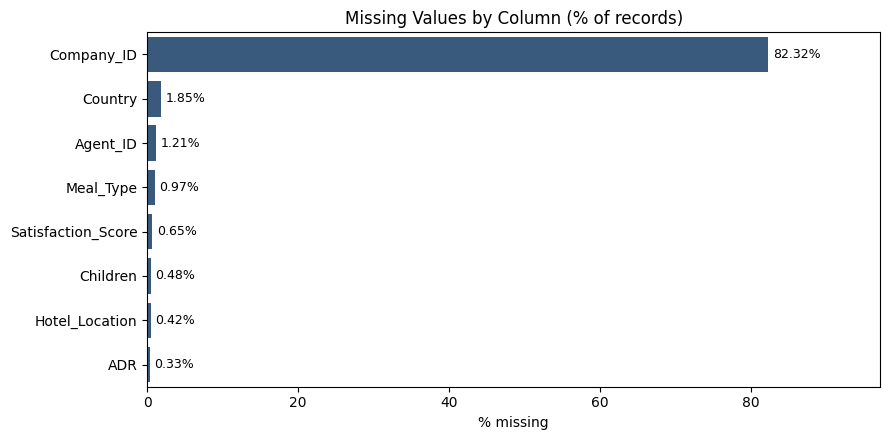

In [20]:
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.barplot(x=missing["missing_pct"], y=missing.index, color=PALETTE[0], ax=ax)
for i, v in enumerate(missing["missing_pct"]):
    ax.text(v + 0.6, i, f"{v:.2f}%", va="center", fontsize=9)
ax.set_title("Missing Values by Column (% of records)")
ax.set_xlabel("% missing")
ax.set_ylabel("")
ax.set_xlim(0, missing["missing_pct"].max() * 1.18)
plt.tight_layout()
plt.show()

In [21]:
full_dupes = df.duplicated().sum()
id_dupes    = df["Booking_ID"].duplicated().sum()

print(f"Fully identical rows      : {full_dupes:,}")
print(f"Repeated Booking_ID values: {id_dupes:,}")
print(f"Share of dataset          : {full_dupes / len(df) * 100:.2f}%")

dup_id = df.loc[df["Booking_ID"].duplicated(keep=False), "Booking_ID"].iloc[0]
df[df["Booking_ID"] == dup_id]

Fully identical rows      : 180
Repeated Booking_ID values: 180
Share of dataset          : 0.71%


,Booking_ID,Hotel_Type,Hotel_Location,Booking_Date,Arrival_Date,Lead_Time_Days,Weekend_Nights,Weekday_Nights,Adults,Children,...,Meal_Type,Total_Nights,ADR,Required_Car_Parking_Spaces,Total_Special_Requests,Satisfaction_Score,Reservation_Status,Is_Canceled,Reservation_Status_Date,Estimated_Revenue
23,HTL000016,Resort Hotel,Maldives,2024-10-27,2025-05-10,195,0,7,2,1.0,...,Undefined,7,168.65,1,0,4.12,Canceled,1,2025-05-16,1180.58
3538,HTL000016,Resort Hotel,Maldives,2024-10-27,2025-05-10,195,0,7,2,1.0,...,Undefined,7,168.65,1,0,4.12,Canceled,1,2025-05-16,1180.58


In [22]:
print("Current dtypes of date columns:")
print(df[DATE_COLS].dtypes, "\n")
print(df[DATE_COLS].head(3))

Current dtypes of date columns:
Booking_Date               object
Arrival_Date               object
Reservation_Status_Date    object
dtype: object 

  Booking_Date Arrival_Date Reservation_Status_Date
0   2024-07-29   2025-07-04              2025-07-07
1   2024-05-28   2025-02-08              2025-02-09
2   2024-05-10   2024-06-20              2024-06-20


In [23]:
check = ["Hotel_Type", "Market_Segment", "Meal_Type", "Hotel_Location",
         "Distribution_Channel", "Deposit_Type", "Customer_Type"]

for col in check:
    vc = df[col].value_counts(dropna=False)
    print(f"--- {col}  ({df[col].nunique()} raw levels) ---")
    print(vc.to_string(), "\n")

--- Hotel_Type  (5 raw levels) ---
Hotel_Type
City Hotel      15606
Resort Hotel     9454
CITY HOTEL         44
city hotel         43
City hotel         33 

--- Market_Segment  (8 raw levels) ---
Market_Segment
Online TA        10782
Offline TA/TO     5483
Direct            3827
Corporate         3012
Groups            1924
ONLINE TA           53
online ta           51
Online TA           48 

--- Meal_Type  (9 raw levels) ---
Meal_Type
BB           5027
Undefined    4978
SC           4945
HB           4939
FB           4939
NaN           245
BB             38
bb             32
 B&B           30
Unknown         7 

--- Hotel_Location  (11 raw levels) ---
Hotel_Location
Dubai        3171
Lisbon       3168
London       3130
Barcelona    3082
Amsterdam    3055
Goa          1966
Algarve      1920
Bali         1893
Maldives     1857
Phuket       1828
NaN           106
Unknown         4 

--- Distribution_Channel  (3 raw levels) ---
Distribution_Channel
TA/TO        17010
Direct        4496

In [24]:
rules = {
    "Arrival before booking date":
        pd.to_datetime(df["Arrival_Date"], errors="coerce") <
        pd.to_datetime(df["Booking_Date"], errors="coerce"),
    "Total_Nights != Weekend + Weekday":
        df["Total_Nights"] != df["Weekend_Nights"] + df["Weekday_Nights"],
    "Zero adults on booking":
        df["Adults"] == 0,
    "Zero-night stay":
        df["Total_Nights"] <= 0,
    "Revenue != ADR x Nights (>1 currency unit)":
        (df["Estimated_Revenue"] - df["ADR"] * df["Total_Nights"]).abs() > 1,
}

viol = pd.Series({k: int(v.sum()) for k, v in rules.items()}, name="violations").to_frame()
viol["pct_of_rows"] = (viol["violations"] / len(df) * 100).round(3)
viol

,violations,pct_of_rows
Arrival before booking date,6,0.024
Total_Nights != Weekend + Weekday,1,0.004
Zero adults on booking,0,0.000
Zero-night stay,0,0.000
Revenue != ADR x Nights (>1 currency unit),3,0.012


In [25]:
def iqr_bounds(s, k=1.5):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

outlier_cols = ["Lead_Time_Days", "ADR", "Total_Nights", "Adults", "Children",
                "Days_In_Waiting_List", "Booking_Changes", "Estimated_Revenue",
                "Satisfaction_Score"]

rows = []
for col in outlier_cols:
    s = df[col].dropna()
    lo, hi = iqr_bounds(s)
    n_out = int(((s < lo) | (s > hi)).sum())
    rows.append({"column": col, "lower_bound": round(lo, 2), "upper_bound": round(hi, 2),
                 "outliers": n_out, "pct": round(n_out / len(s) * 100, 2),
                 "min": s.min(), "max": s.max()})

outlier_tbl = pd.DataFrame(rows).sort_values("pct", ascending=False)
outlier_tbl

,column,lower_bound,upper_bound,outliers,pct,min,max
3,Adults,2.00,2.00,7586,30.13,1.00,7.00
5,Days_In_Waiting_List,-1.50,2.50,4108,16.31,0.00,180.00
6,Booking_Changes,-1.50,2.50,1287,5.11,0.00,4.00
7,Estimated_Revenue,-530.02,1498.13,659,2.62,31.82,3256.02
1,ADR,10.40,264.31,359,1.43,30.80,710.50
8,Satisfaction_Score,2.78,4.94,249,1.00,0.30,5.90
4,Children,-1.50,2.50,212,0.85,0.00,6.00
2,Total_Nights,-2.50,9.50,137,0.54,1.00,45.00
0,Lead_Time_Days,-182.00,546.00,2,0.01,0.00,920.00


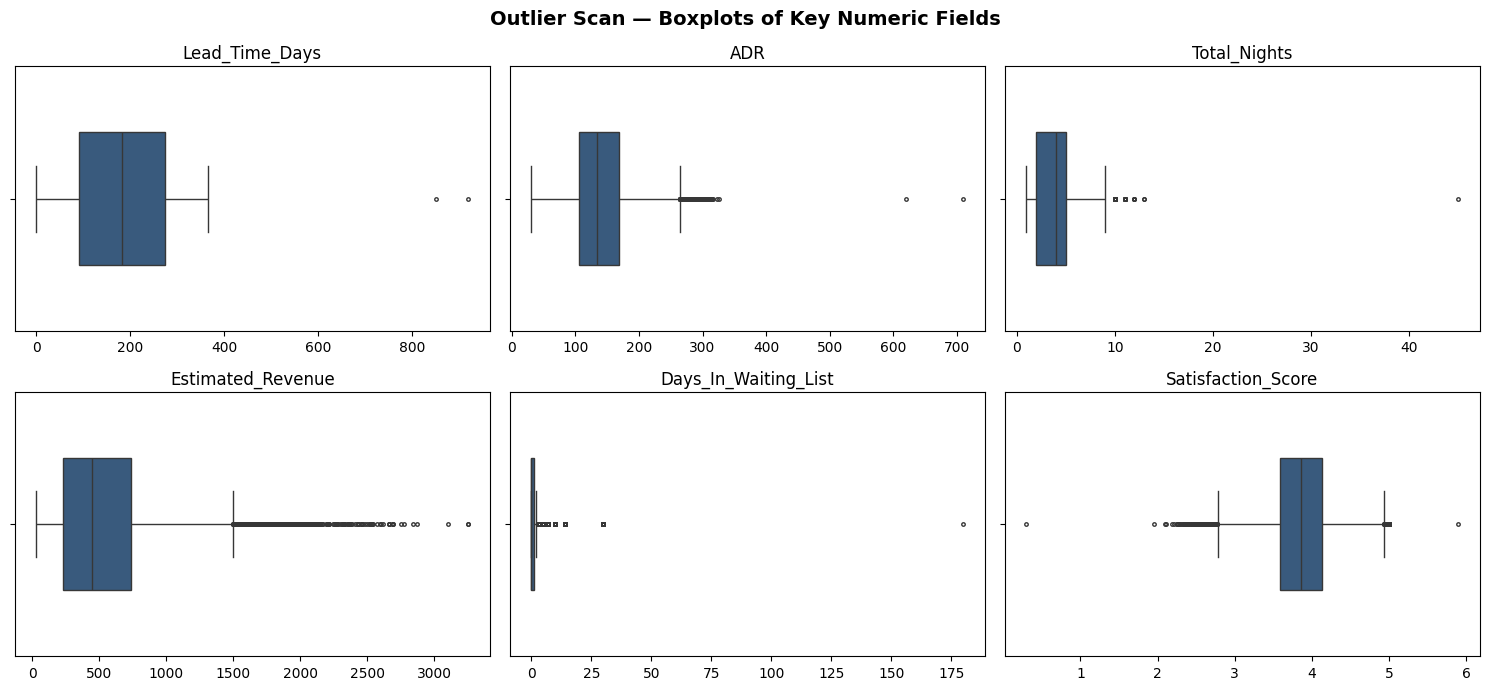

In [26]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, col in zip(axes.ravel(), ["Lead_Time_Days", "ADR", "Total_Nights",
                                  "Estimated_Revenue", "Days_In_Waiting_List",
                                  "Satisfaction_Score"]):
    sns.boxplot(x=df[col], ax=ax, color=PALETTE[0], fliersize=2.5, width=0.5)
    ax.set_title(col)
    ax.set_xlabel("")
fig.suptitle("Outlier Scan — Boxplots of Key Numeric Fields", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [27]:
scorecard = pd.DataFrame([
    ["Missing values",     f"{int(df.isna().sum().sum()):,} cells across 8 columns", "Impute / flag"],
    ["Duplicate rows",     f"{full_dupes:,} exact duplicates ({full_dupes/len(df)*100:.2f}%)", "Drop"],
    ["Incorrect dtypes",   "3 date columns stored as text",                    "Convert to datetime"],
    ["Inconsistent labels","Case/whitespace variants in 3 columns",            "Standardise"],
    ["Placeholder values", '"Unknown" / "Undefined" strings',                  "Map to NaN or explicit level"],
    ["Logical errors",     "10 rows violate business rules",                   "Drop or correct"],
    ["Outliers",           "ADR, Lead_Time, Total_Nights long right tails",    "Retain, cap for plots"],
    ["Target leakage",     "Reservation_Status encodes Is_Canceled",           "Exclude from correlations"],
], columns=["Issue", "Observed", "Treatment"])
scorecard.style.hide(axis="index")

Issue,Observed,Treatment
Missing values,"22,217 cells across 8 columns",Impute / flag
Duplicate rows,180 exact duplicates (0.71%),Drop
Incorrect dtypes,3 date columns stored as text,Convert to datetime
Inconsistent labels,Case/whitespace variants in 3 columns,Standardise
Placeholder values,"""Unknown"" / ""Undefined"" strings",Map to NaN or explicit level
Logical errors,10 rows violate business rules,Drop or correct
Outliers,"ADR, Lead_Time, Total_Nights long right tails","Retain, cap for plots"
Target leakage,Reservation_Status encodes Is_Canceled,Exclude from correlations


In [29]:
clean = df.copy()
log = []

def record(step, before, after):
    log.append({"step": step, "rows_before": before, "rows_after": after,
                "rows_removed": before - after})

n0 = len(clean)
clean = clean.drop_duplicates()
record("Drop exact duplicates", n0, len(clean))
print(f"Removed {n0 - len(clean):,} duplicate rows")

Removed 180 duplicate rows


In [30]:
def tidy(s):
    """Strip whitespace and collapse casing variants."""
    return s.astype("string").str.strip().str.title()

for col in ["Hotel_Type", "Hotel_Location", "Market_Segment", "Customer_Type",
            "Distribution_Channel", "Deposit_Type", "Reservation_Status"]:
    clean[col] = tidy(clean[col])

clean["Market_Segment"] = clean["Market_Segment"].replace({
    "Online Ta": "Online TA", "Offline Ta/To": "Offline TA/TO",
})
clean["Distribution_Channel"] = clean["Distribution_Channel"].replace({"Ta/To": "TA/TO"})

meal_map = {"BB": "BB", "B&B": "BB", "HB": "HB", "FB": "FB", "SC": "SC",
            "UNDEFINED": "Undefined", "UNKNOWN": np.nan}
clean["Meal_Type"] = (clean["Meal_Type"].astype("string").str.strip().str.upper()
                                        .map(meal_map))

clean["Hotel_Location"] = clean["Hotel_Location"].replace({"Unknown": np.nan})

for col in ["Hotel_Type", "Market_Segment", "Meal_Type", "Hotel_Location"]:
    print(f"{col:<18} -> {sorted(clean[col].dropna().unique())}")

Hotel_Type         -> ['City Hotel', 'Resort Hotel']
Market_Segment     -> ['Corporate', 'Direct', 'Groups', 'Offline TA/TO', 'Online TA']
Meal_Type          -> ['BB', 'FB', 'HB', 'SC', 'Undefined']
Hotel_Location     -> ['Algarve', 'Amsterdam', 'Bali', 'Barcelona', 'Dubai', 'Goa', 'Lisbon', 'London', 'Maldives', 'Phuket']


In [31]:
for col in DATE_COLS:
    clean[col] = pd.to_datetime(clean[col], errors="coerce")

print(clean[DATE_COLS].dtypes)
print()
print("Booking window:", clean["Booking_Date"].min().date(), "->", clean["Booking_Date"].max().date())
print("Arrival window:", clean["Arrival_Date"].min().date(), "->", clean["Arrival_Date"].max().date())

Booking_Date               datetime64[ns]
Arrival_Date               datetime64[ns]
Reservation_Status_Date    datetime64[ns]
dtype: object

Booking window: 2024-01-01 -> 2025-12-31
Arrival window: 2024-01-02 -> 2026-12-29


In [32]:
before = clean.isna().sum().loc[lambda s: s > 0]

clean["Is_Corporate_Booking"] = clean["Company_ID"].notna().astype(int)
clean = clean.drop(columns=["Company_ID"])

clean["Agent_ID"] = clean["Agent_ID"].fillna(0)
clean["Booked_Via_Agent"] = (clean["Agent_ID"] > 0).astype(int)

clean["Children"] = clean["Children"].fillna(0).astype(int)

clean["ADR"] = clean["ADR"].fillna(
    clean.groupby(["Hotel_Type"])["ADR"].transform("median")
)

clean["Satisfaction_Score"] = clean["Satisfaction_Score"].fillna(
    clean["Satisfaction_Score"].median()
)

clean["Hotel_Location"] = clean["Hotel_Location"].fillna(clean["Hotel_Location"].mode()[0])
clean["Meal_Type"]      = clean["Meal_Type"].fillna("Undefined")
clean["Country"]        = clean["Country"].fillna("UNK")

after = clean.isna().sum().loc[lambda s: s > 0]
print("Remaining missing values:", after.to_dict() if len(after) else "none")

Remaining missing values: none


In [34]:
clean["Arrival_Year"]    = clean["Arrival_Date"].dt.year
clean["Arrival_Month"]   = clean["Arrival_Date"].dt.month
clean["Arrival_Month_Name"] = clean["Arrival_Date"].dt.strftime("%b")
clean["Arrival_Quarter"] = "Q" + clean["Arrival_Date"].dt.quarter.astype(str)
clean["Arrival_Weekday"] = clean["Arrival_Date"].dt.day_name()

clean["Total_Guests"] = clean["Adults"] + clean["Children"] + clean["Babies"]
clean["Has_Kids"]     = ((clean["Children"] + clean["Babies"]) > 0).astype(int)

clean["Room_Type_Changed"] = (clean["Room_Type_Reserved"] != clean["Room_Type_Assigned"]).astype(int)
clean["Has_Special_Request"] = (clean["Total_Special_Requests"] > 0).astype(int)

clean["Lead_Time_Band"] = pd.cut(
    clean["Lead_Time_Days"],
    bins=[-1, 30, 90, 180, 365, np.inf],
    labels=["0-30 d", "31-90 d", "91-180 d", "181-365 d", "365+ d"],
)

clean["Revenue_Per_Guest"] = (clean["Estimated_Revenue"] / clean["Total_Guests"]).round(2)

clean["Season"] = np.where(clean["Arrival_Month"].isin([6, 7, 8, 12]), "Peak", "Off-Peak")

clean[["Arrival_Month_Name", "Lead_Time_Band", "Total_Guests", "Season",
       "Room_Type_Changed", "Revenue_Per_Guest"]].head()

,Arrival_Month_Name,Lead_Time_Band,Total_Guests,Season,Room_Type_Changed,Revenue_Per_Guest
0,Jul,181-365 d,2,Peak,0,357.32
1,Feb,181-365 d,4,Off-Peak,0,94.36
2,Jun,31-90 d,4,Peak,0,74.02
3,Apr,0-30 d,2,Off-Peak,0,166.82
4,May,181-365 d,4,Off-Peak,0,57.62


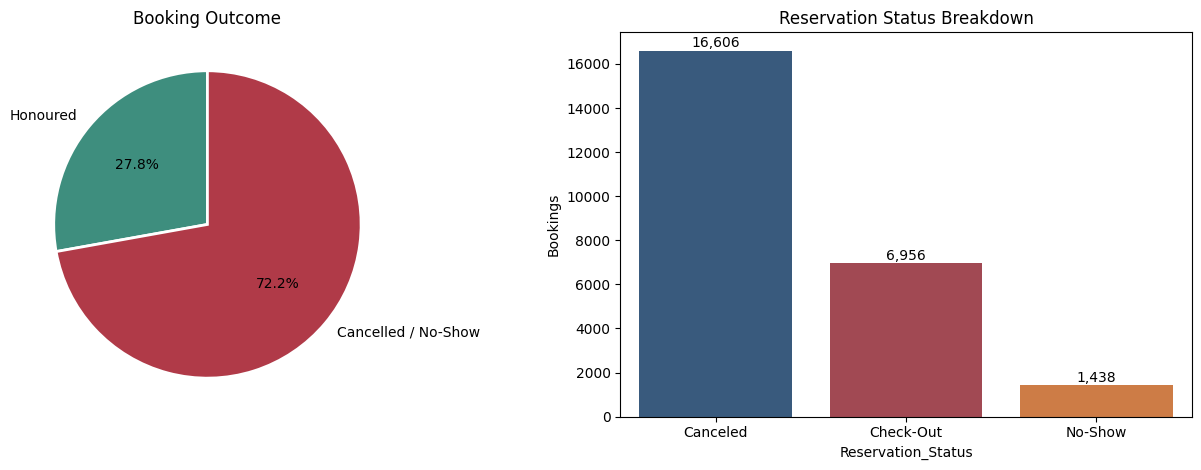

Overall cancellation rate: 72.2%


In [35]:
cancel_rate = clean["Is_Canceled"].mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

counts = clean["Is_Canceled"].value_counts().sort_index()
axes[0].pie(counts, labels=["Honoured", "Cancelled / No-Show"], autopct="%1.1f%%",
            colors=[PALETTE[2], PALETTE[3]], startangle=90,
            wedgeprops={"edgecolor": "white", "linewidth": 2})
axes[0].set_title("Booking Outcome")

status = clean["Reservation_Status"].value_counts()
sns.barplot(x=status.index, y=status.values, hue=status.index, legend=False,
            palette=[PALETTE[0], PALETTE[3], PALETTE[1]], ax=axes[1])
for i, v in enumerate(status.values):
    axes[1].text(i, v + 150, f"{v:,}", ha="center", fontsize=10)
axes[1].set_title("Reservation Status Breakdown")
axes[1].set_ylabel("Bookings")

plt.tight_layout()
plt.show()

print(f"Overall cancellation rate: {cancel_rate:.1%}")

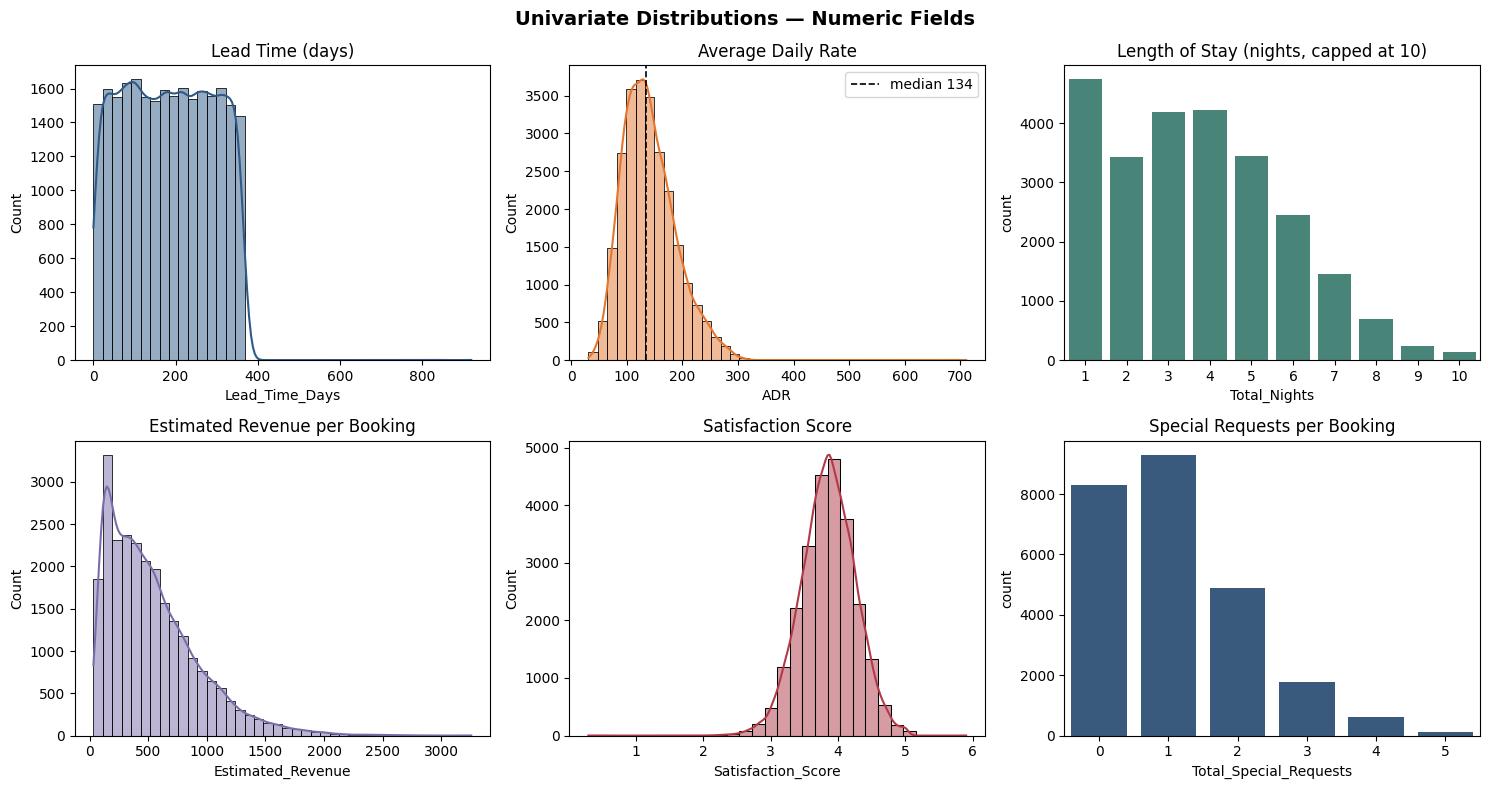

In [36]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

sns.histplot(clean["Lead_Time_Days"], bins=40, kde=True, color=PALETTE[0], ax=axes[0, 0])
axes[0, 0].set_title("Lead Time (days)")

sns.histplot(clean["ADR"], bins=40, kde=True, color=PALETTE[1], ax=axes[0, 1])
axes[0, 1].axvline(clean["ADR"].median(), ls="--", color="black", lw=1.2,
                   label=f"median {clean['ADR'].median():.0f}")
axes[0, 1].legend()
axes[0, 1].set_title("Average Daily Rate")

sns.countplot(x=clean["Total_Nights"].clip(upper=10), color=PALETTE[2], ax=axes[0, 2])
axes[0, 2].set_title("Length of Stay (nights, capped at 10)")
axes[0, 2].set_xlabel("Total_Nights")

sns.histplot(clean["Estimated_Revenue"], bins=40, kde=True, color=PALETTE[4], ax=axes[1, 0])
axes[1, 0].set_title("Estimated Revenue per Booking")

sns.histplot(clean["Satisfaction_Score"], bins=30, kde=True, color=PALETTE[3], ax=axes[1, 1])
axes[1, 1].set_title("Satisfaction Score")

sns.countplot(x=clean["Total_Special_Requests"], color=PALETTE[0], ax=axes[1, 2])
axes[1, 2].set_title("Special Requests per Booking")

fig.suptitle("Univariate Distributions — Numeric Fields", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

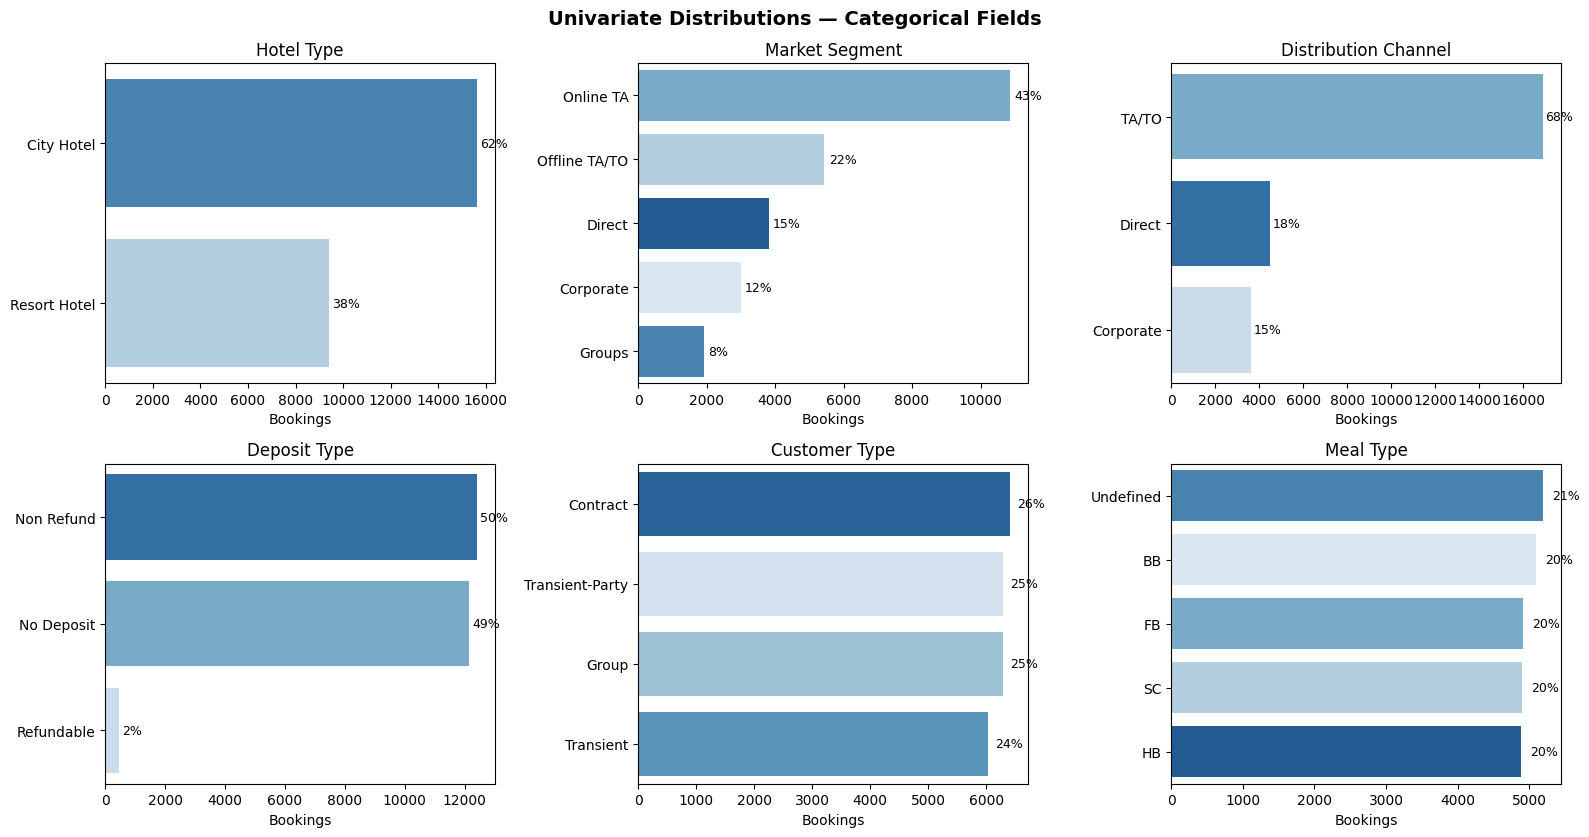

In [37]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8.5))
cat_plots = ["Hotel_Type", "Market_Segment", "Distribution_Channel",
             "Deposit_Type", "Customer_Type", "Meal_Type"]

for ax, col in zip(axes.ravel(), cat_plots):
    order = clean[col].value_counts().index
    sns.countplot(y=clean[col], order=order, hue=clean[col], legend=False,
                  palette="Blues_r", ax=ax)
    total = len(clean)
    for p in ax.patches:
        w = p.get_width()
        ax.text(w + total * 0.005, p.get_y() + p.get_height() / 2,
                f"{w / total:.0%}", va="center", fontsize=9)
    ax.set_title(col.replace("_", " "))
    ax.set_ylabel("")
    ax.set_xlabel("Bookings")

fig.suptitle("Univariate Distributions — Categorical Fields", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [38]:
loc = (clean.groupby("Hotel_Location")
            .agg(bookings=("Booking_ID", "size"),
                 avg_adr=("ADR", "mean"),
                 revenue=("Estimated_Revenue", "sum"))
            .sort_values("bookings", ascending=False))
loc["share_%"] = (loc["bookings"] / loc["bookings"].sum() * 100).round(1)
loc

,bookings,avg_adr,revenue,share_%
Hotel_Location,,,,
Dubai,3257,121.769407,1280542.59,13.0
Lisbon,3148,120.564495,1198314.63,12.6
London,3106,121.479169,1207466.30,12.4
Barcelona,3061,120.321375,1175082.43,12.2
Amsterdam,3029,119.236613,1149330.24,12.1
Goa,1957,174.336495,1568006.15,7.8
Algarve,1902,174.507792,1471887.02,7.6
Bali,1882,173.863247,1494345.71,7.5
Maldives,1845,173.008070,1435469.77,7.4


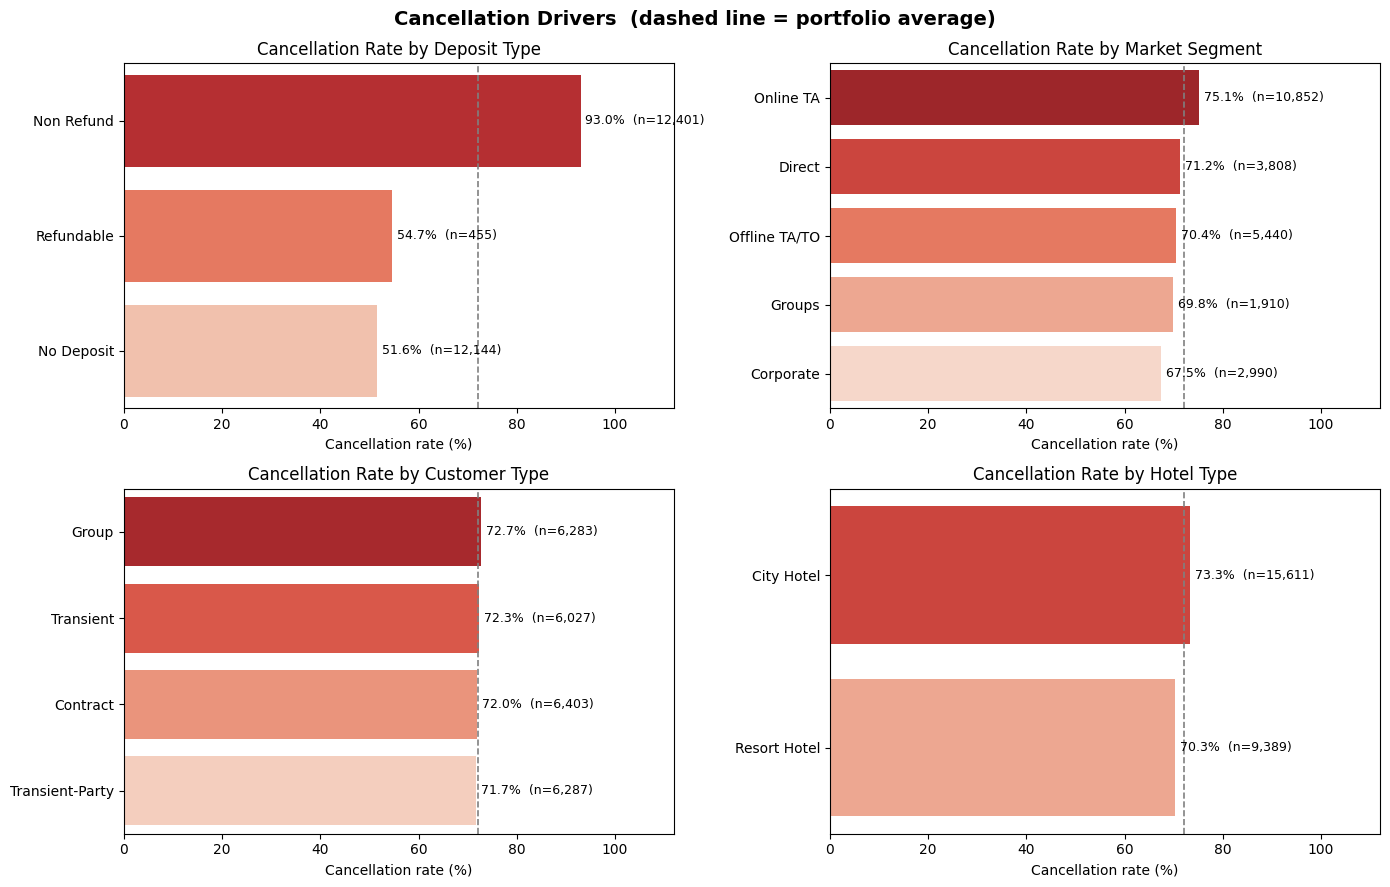

In [39]:
def rate_by(col, data=clean, min_n=50):
    """Cancellation rate and volume for each level of a column."""
    g = (data.groupby(col, observed=True)
             .agg(bookings=("Is_Canceled", "size"),
                  cancel_rate=("Is_Canceled", "mean"))
             .query("bookings >= @min_n")
             .sort_values("cancel_rate", ascending=False))
    g["cancel_rate"] = (g["cancel_rate"] * 100).round(1)
    return g

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, col in zip(axes.ravel(), ["Deposit_Type", "Market_Segment",
                                  "Customer_Type", "Hotel_Type"]):
    g = rate_by(col)
    sns.barplot(x=g["cancel_rate"], y=g.index, hue=g.index, legend=False,
                palette="Reds_r", ax=ax)
    for i, (v, n) in enumerate(zip(g["cancel_rate"], g["bookings"])):
        ax.text(v + 1, i, f"{v:.1f}%  (n={n:,})", va="center", fontsize=9)
    ax.axvline(cancel_rate * 100, ls="--", color="grey", lw=1.2)
    ax.set_xlim(0, 112)
    ax.set_title(f"Cancellation Rate by {col.replace('_', ' ')}")
    ax.set_xlabel("Cancellation rate (%)")
    ax.set_ylabel("")

fig.suptitle("Cancellation Drivers  (dashed line = portfolio average)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

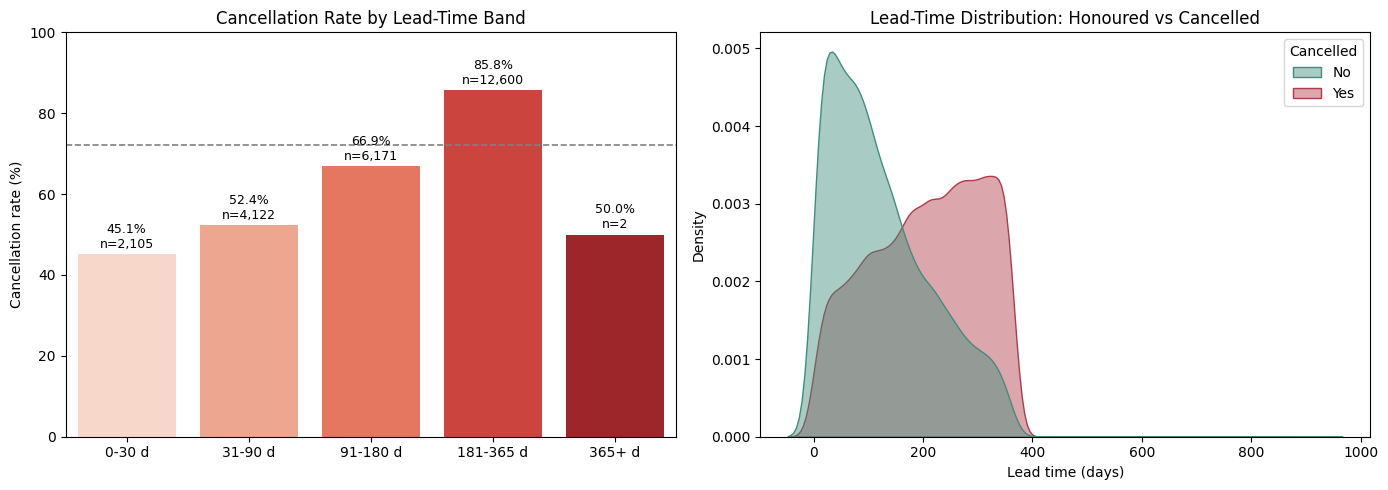

,bookings,cancel_rate
Lead_Time_Band,,
0-30 d,2105,45.1
31-90 d,4122,52.4
91-180 d,6171,66.9
181-365 d,12600,85.8
365+ d,2,50.0


In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

g = (clean.groupby("Lead_Time_Band", observed=True)
          .agg(bookings=("Is_Canceled", "size"), cancel_rate=("Is_Canceled", "mean")))
g["cancel_rate"] *= 100

sns.barplot(x=g.index, y=g["cancel_rate"], hue=g.index, legend=False,
            palette="Reds", ax=axes[0])
for i, (v, n) in enumerate(zip(g["cancel_rate"], g["bookings"])):
    axes[0].text(i, v + 1.5, f"{v:.1f}%\nn={n:,}", ha="center", fontsize=9)
axes[0].axhline(cancel_rate * 100, ls="--", color="grey", lw=1.2)
axes[0].set_ylim(0, 100)
axes[0].set_title("Cancellation Rate by Lead-Time Band")
axes[0].set_ylabel("Cancellation rate (%)")
axes[0].set_xlabel("")

sns.kdeplot(data=clean, x="Lead_Time_Days", hue="Is_Canceled", fill=True,
            common_norm=False, alpha=0.45,
            palette=[PALETTE[2], PALETTE[3]], ax=axes[1])
axes[1].set_title("Lead-Time Distribution: Honoured vs Cancelled")
axes[1].set_xlabel("Lead time (days)")
axes[1].legend_.set_title("Cancelled")
axes[1].legend_.texts[0].set_text("No")
axes[1].legend_.texts[1].set_text("Yes")

plt.tight_layout()
plt.show()

display(g.round(1))

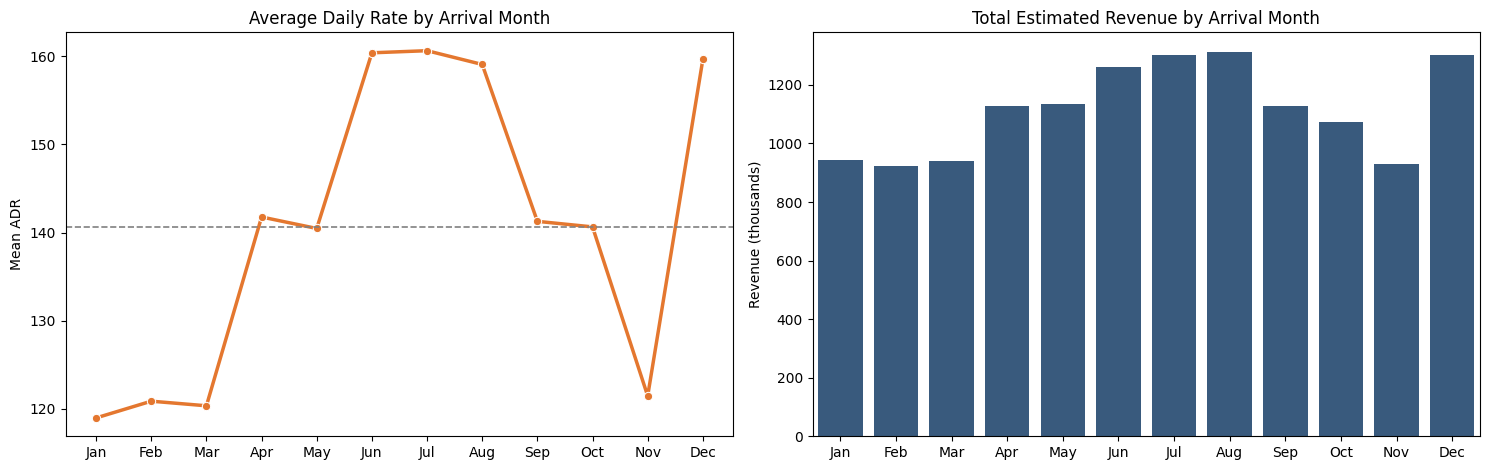

,bookings,avg_adr,revenue,cancel_rate
Arrival_Month,,,,
Jan,2108,118.95,943640.63,72.9
Feb,2003,120.85,922646.09,70.7
Mar,2056,120.33,941192.08,73.3
Apr,2072,141.76,1127460.76,72.2
May,2108,140.46,1135105.06,71.3
Jun,2068,160.40,1262335.88,73.4
Jul,2129,160.64,1301370.55,71.0
Aug,2131,159.08,1313959.11,73.2
Sep,2108,141.27,1128060.26,72.9


In [41]:
monthly = (clean.groupby("Arrival_Month", observed=True)
                .agg(bookings=("Booking_ID", "size"),
                     avg_adr=("ADR", "mean"),
                     revenue=("Estimated_Revenue", "sum"),
                     cancel_rate=("Is_Canceled", "mean")))
monthly.index = pd.to_datetime(monthly.index, format="%m").strftime("%b")

fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))

ax1 = axes[0]
sns.lineplot(x=monthly.index, y=monthly["avg_adr"], marker="o",
             color=PALETTE[1], lw=2.5, ax=ax1)
ax1.set_title("Average Daily Rate by Arrival Month")
ax1.set_ylabel("Mean ADR")
ax1.set_xlabel("")
ax1.axhline(clean["ADR"].mean(), ls="--", color="grey", lw=1.2)

ax2 = axes[1]
sns.barplot(x=monthly.index, y=monthly["revenue"] / 1000, color=PALETTE[0], ax=ax2)
ax2.set_title("Total Estimated Revenue by Arrival Month")
ax2.set_ylabel("Revenue (thousands)")
ax2.set_xlabel("")

plt.tight_layout()
plt.show()

display(monthly.assign(cancel_rate=lambda d: (d["cancel_rate"] * 100).round(1)).round(2))

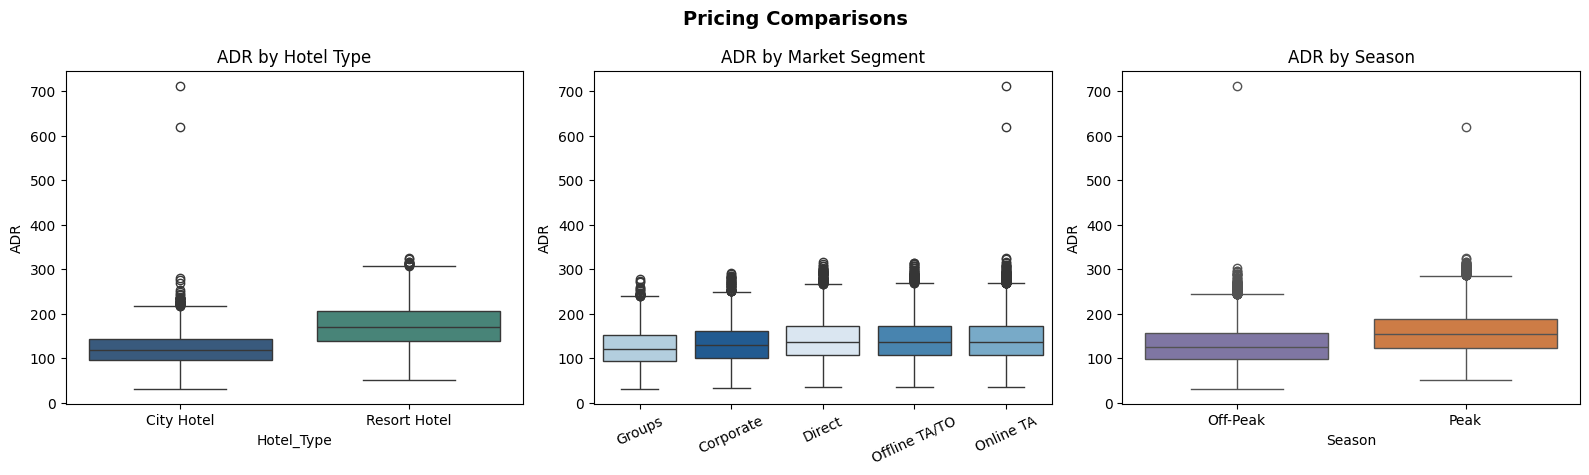

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

sns.boxplot(data=clean, x="Hotel_Type", y="ADR", hue="Hotel_Type", legend=False,
            palette=[PALETTE[0], PALETTE[2]], ax=axes[0])
axes[0].set_title("ADR by Hotel Type")

sns.boxplot(data=clean, x="Market_Segment", y="ADR", hue="Market_Segment", legend=False,
            palette="Blues", ax=axes[1],
            order=clean.groupby("Market_Segment")["ADR"].median().sort_values().index)
axes[1].set_title("ADR by Market Segment")
axes[1].tick_params(axis="x", rotation=25)
axes[1].set_xlabel("")

sns.boxplot(data=clean, x="Season", y="ADR", hue="Season", legend=False,
            palette=[PALETTE[1], PALETTE[4]], ax=axes[2], order=["Off-Peak", "Peak"])
axes[2].set_title("ADR by Season")

fig.suptitle("Pricing Comparisons", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

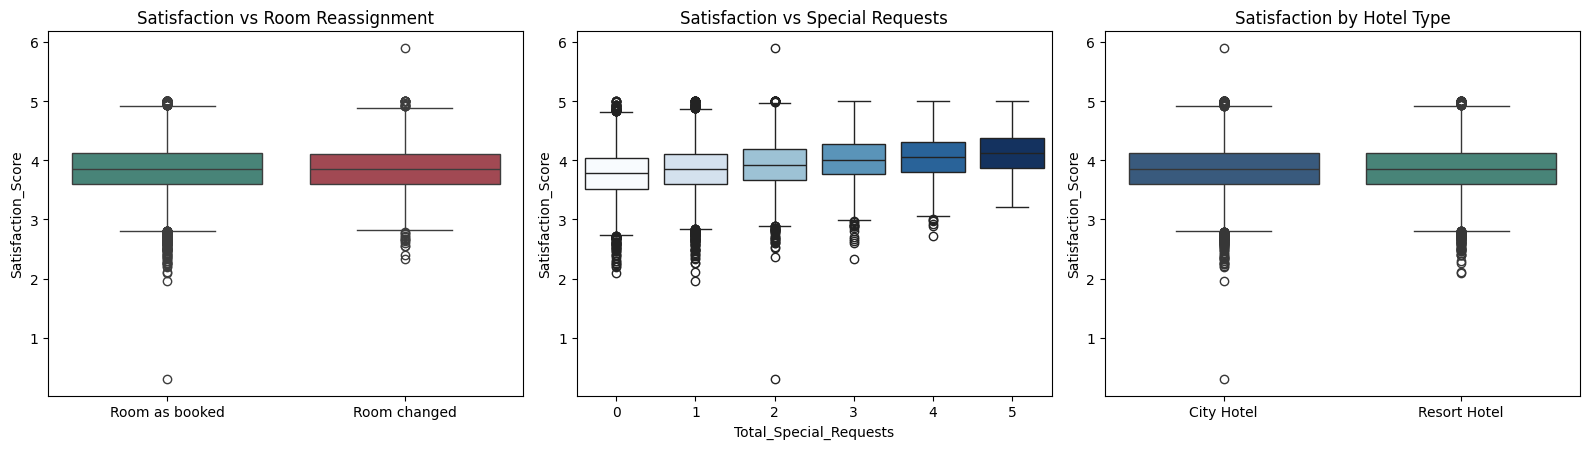

                    mean  median   size
Room_Type_Changed                      
0                  3.855    3.86  22013
1                  3.849    3.86   2987


In [43]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))

sns.boxplot(data=clean, x="Room_Type_Changed", y="Satisfaction_Score",
            hue="Room_Type_Changed", legend=False,
            palette=[PALETTE[2], PALETTE[3]], ax=axes[0])
axes[0].set_xticks([0, 1]); axes[0].set_xticklabels(["Room as booked", "Room changed"])
axes[0].set_title("Satisfaction vs Room Reassignment")
axes[0].set_xlabel("")

sns.boxplot(data=clean, x="Total_Special_Requests", y="Satisfaction_Score",
            hue="Total_Special_Requests", legend=False, palette="Blues", ax=axes[1])
axes[1].set_title("Satisfaction vs Special Requests")

sns.boxplot(data=clean, x="Hotel_Type", y="Satisfaction_Score",
            hue="Hotel_Type", legend=False,
            palette=[PALETTE[0], PALETTE[2]], ax=axes[2])
axes[2].set_title("Satisfaction by Hotel Type")
axes[2].set_xlabel("")

plt.tight_layout()
plt.show()

print(clean.groupby("Room_Type_Changed")["Satisfaction_Score"].agg(["mean", "median", "size"]).round(3))

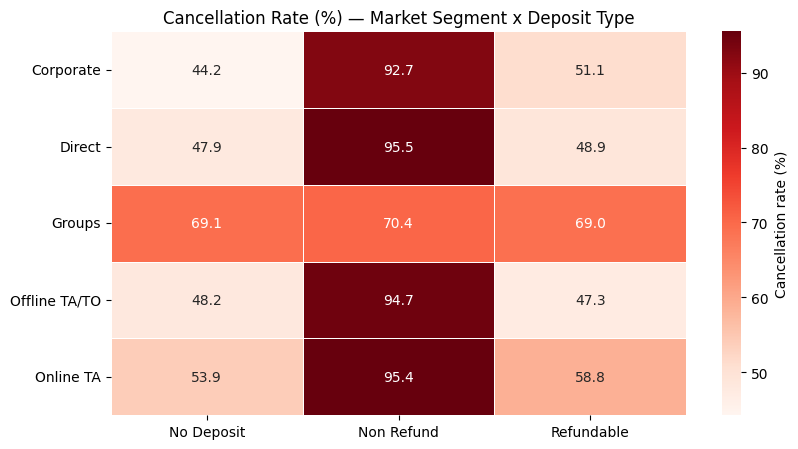

In [44]:
pivot = (clean.pivot_table(index="Market_Segment", columns="Deposit_Type",
                           values="Is_Canceled", aggfunc="mean") * 100)

fig, ax = plt.subplots(figsize=(8.5, 4.6))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="Reds", linewidths=0.6,
            cbar_kws={"label": "Cancellation rate (%)"}, ax=ax)
ax.set_title("Cancellation Rate (%) — Market Segment x Deposit Type")
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

In [45]:
def perf_table(by):
    t = (clean.groupby(by, observed=True)
              .agg(Bookings=("Booking_ID", "size"),
                   Cancel_Rate=("Is_Canceled", "mean"),
                   Avg_ADR=("ADR", "mean"),
                   Avg_Nights=("Total_Nights", "mean"),
                   Avg_Lead_Time=("Lead_Time_Days", "mean"),
                   Avg_Satisfaction=("Satisfaction_Score", "mean"),
                   Total_Revenue=("Estimated_Revenue", "sum")))
    t["Cancel_Rate"] = (t["Cancel_Rate"] * 100).round(1)
    t["Realised_Revenue"] = (clean[clean["Is_Canceled"] == 0]
                             .groupby(by, observed=True)["Estimated_Revenue"].sum())
    t["Revenue_At_Risk"] = t["Total_Revenue"] - t["Realised_Revenue"]
    return t.round(2).sort_values("Total_Revenue", ascending=False)

print("=== Performance by Hotel Type ===")
display(perf_table("Hotel_Type"))

print("=== Performance by Market Segment ===")
display(perf_table("Market_Segment"))

=== Performance by Hotel Type ===


,Bookings,Cancel_Rate,Avg_ADR,Avg_Nights,Avg_Lead_Time,Avg_Satisfaction,Total_Revenue,Realised_Revenue,Revenue_At_Risk
Hotel_Type,,,,,,,,,
Resort Hotel,9389,70.3,173.68,4.52,181.03,3.86,7365874.95,2193725.59,5172149.36
City Hotel,15611,73.3,120.71,3.20,182.93,3.85,6018324.50,1587048.28,4431276.22


=== Performance by Market Segment ===


,Bookings,Cancel_Rate,Avg_ADR,Avg_Nights,Avg_Lead_Time,Avg_Satisfaction,Total_Revenue,Realised_Revenue,Revenue_At_Risk
Market_Segment,,,,,,,,,
Online TA,10852,75.1,143.23,3.70,181.75,3.86,5932008.25,1503935.18,4428073.07
Offline TA/TO,5440,70.4,142.40,3.68,182.30,3.85,2944293.73,883744.96,2060548.77
Direct,3808,71.2,143.27,3.71,183.59,3.85,2098049.99,628471.77,1469578.22
Corporate,2990,67.5,134.16,3.62,181.04,3.86,1492611.61,491772.15,1000839.46
Groups,1910,69.8,125.36,3.74,183.75,3.85,917235.87,272849.81,644386.06


In [46]:
print("=== Performance by Property Location ===")
display(perf_table("Hotel_Location"))

print("=== Performance by Customer Type ===")
display(perf_table("Customer_Type"))

=== Performance by Property Location ===


,Bookings,Cancel_Rate,Avg_ADR,Avg_Nights,Avg_Lead_Time,Avg_Satisfaction,Total_Revenue,Realised_Revenue,Revenue_At_Risk
Hotel_Location,,,,,,,,,
Goa,1957,68.0,174.34,4.58,180.59,3.86,1568006.15,506523.20,1061482.95
Bali,1882,70.7,173.86,4.58,181.48,3.87,1494345.71,437845.91,1056499.80
Algarve,1902,71.1,174.51,4.45,180.59,3.86,1471887.02,405795.56,1066091.46
Maldives,1845,71.5,173.01,4.49,181.83,3.86,1435469.77,424681.77,1010788.00
Phuket,1813,70.3,172.46,4.49,180.67,3.85,1403754.61,420459.44,983295.17
Dubai,3257,73.5,121.77,3.23,184.15,3.86,1280542.59,338113.48,942429.11
London,3106,74.0,121.48,3.20,183.36,3.84,1207466.30,309465.86,898000.44
Lisbon,3148,73.2,120.56,3.16,182.89,3.86,1198314.63,318834.54,879480.09
Barcelona,3061,73.4,120.32,3.20,183.76,3.84,1175082.43,308627.47,866454.96


=== Performance by Customer Type ===


,Bookings,Cancel_Rate,Avg_ADR,Avg_Nights,Avg_Lead_Time,Avg_Satisfaction,Total_Revenue,Realised_Revenue,Revenue_At_Risk
Customer_Type,,,,,,,,,
Contract,6403,72.0,140.75,3.71,182.09,3.86,3461023.69,985074.00,2475949.69
Group,6283,72.7,140.61,3.69,182.98,3.85,3355007.34,915393.35,2439613.99
Transient-Party,6287,71.7,139.89,3.66,181.73,3.85,3317076.65,939699.60,2377377.05
Transient,6027,72.3,141.19,3.70,182.06,3.86,3251091.77,940606.92,2310484.85


In [47]:
total_booked   = clean["Estimated_Revenue"].sum()
realised       = clean.loc[clean["Is_Canceled"] == 0, "Estimated_Revenue"].sum()
lost           = total_booked - realised

print(f"Gross booked revenue : {total_booked:>15,.0f}")
print(f"Realised revenue     : {realised:>15,.0f}  ({realised/total_booked:.1%})")
print(f"Revenue lost to cancellation/no-show: {lost:>10,.0f}  ({lost/total_booked:.1%})")
print()
print(f"Average value of a cancelled booking : {clean.loc[clean['Is_Canceled']==1,'Estimated_Revenue'].mean():,.2f}")
print(f"Average value of an honoured booking : {clean.loc[clean['Is_Canceled']==0,'Estimated_Revenue'].mean():,.2f}")

Gross booked revenue :      13,384,199
Realised revenue     :       3,780,774  (28.2%)
Revenue lost to cancellation/no-show:  9,603,426  (71.8%)

Average value of a cancelled booking : 532.22
Average value of an honoured booking : 543.53


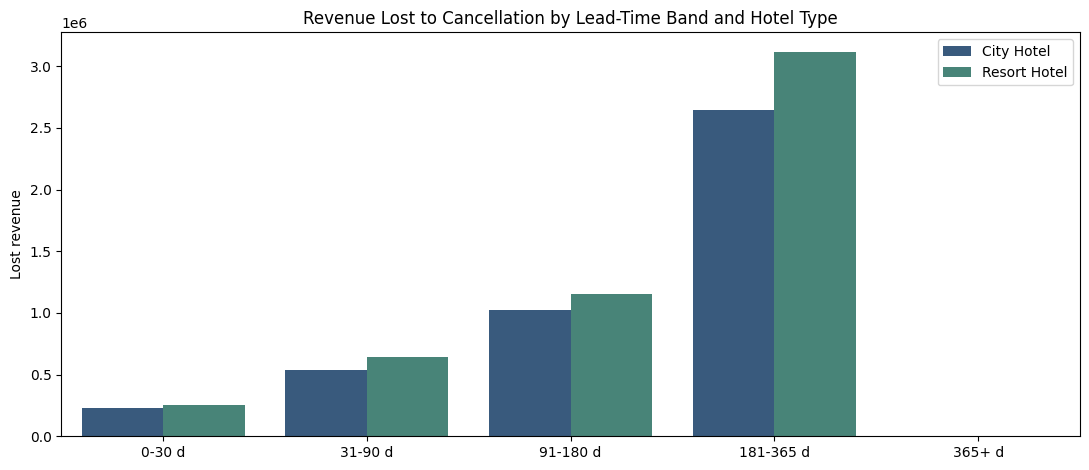

,Hotel_Type,Lead_Time_Band,Bookings,Cancel_Rate,Rev_At_Risk
8,Resort Hotel,181-365 d,4718,84.0,3119182.0
3,City Hotel,181-365 d,7882,87.0,2642216.0
7,Resort Hotel,91-180 d,2296,65.0,1157014.0
2,City Hotel,91-180 d,3875,68.0,1024093.0
6,Resort Hotel,31-90 d,1598,50.0,639281.0
1,City Hotel,31-90 d,2524,54.0,536068.0
5,Resort Hotel,0-30 d,776,44.0,256673.0
0,City Hotel,0-30 d,1329,46.0,228737.0
4,City Hotel,365+ d,1,100.0,162.0
9,Resort Hotel,365+ d,1,0.0,0.0


In [48]:
risk = (clean.groupby(["Hotel_Type", "Lead_Time_Band"], observed=True)
             .agg(Bookings=("Booking_ID", "size"),
                  Cancel_Rate=("Is_Canceled", "mean"),
                  Rev_At_Risk=("Estimated_Revenue", lambda s: s[clean.loc[s.index, "Is_Canceled"] == 1].sum()))
             .reset_index())
risk["Cancel_Rate"] = (risk["Cancel_Rate"] * 100).round(1)

fig, ax = plt.subplots(figsize=(11, 4.8))
sns.barplot(data=risk, x="Lead_Time_Band", y="Rev_At_Risk", hue="Hotel_Type",
            palette=[PALETTE[0], PALETTE[2]], ax=ax)
ax.set_title("Revenue Lost to Cancellation by Lead-Time Band and Hotel Type")
ax.set_ylabel("Lost revenue")
ax.set_xlabel("")
ax.legend(title="")
plt.tight_layout()
plt.show()

display(risk.sort_values("Rev_At_Risk", ascending=False).head(10).round(0))

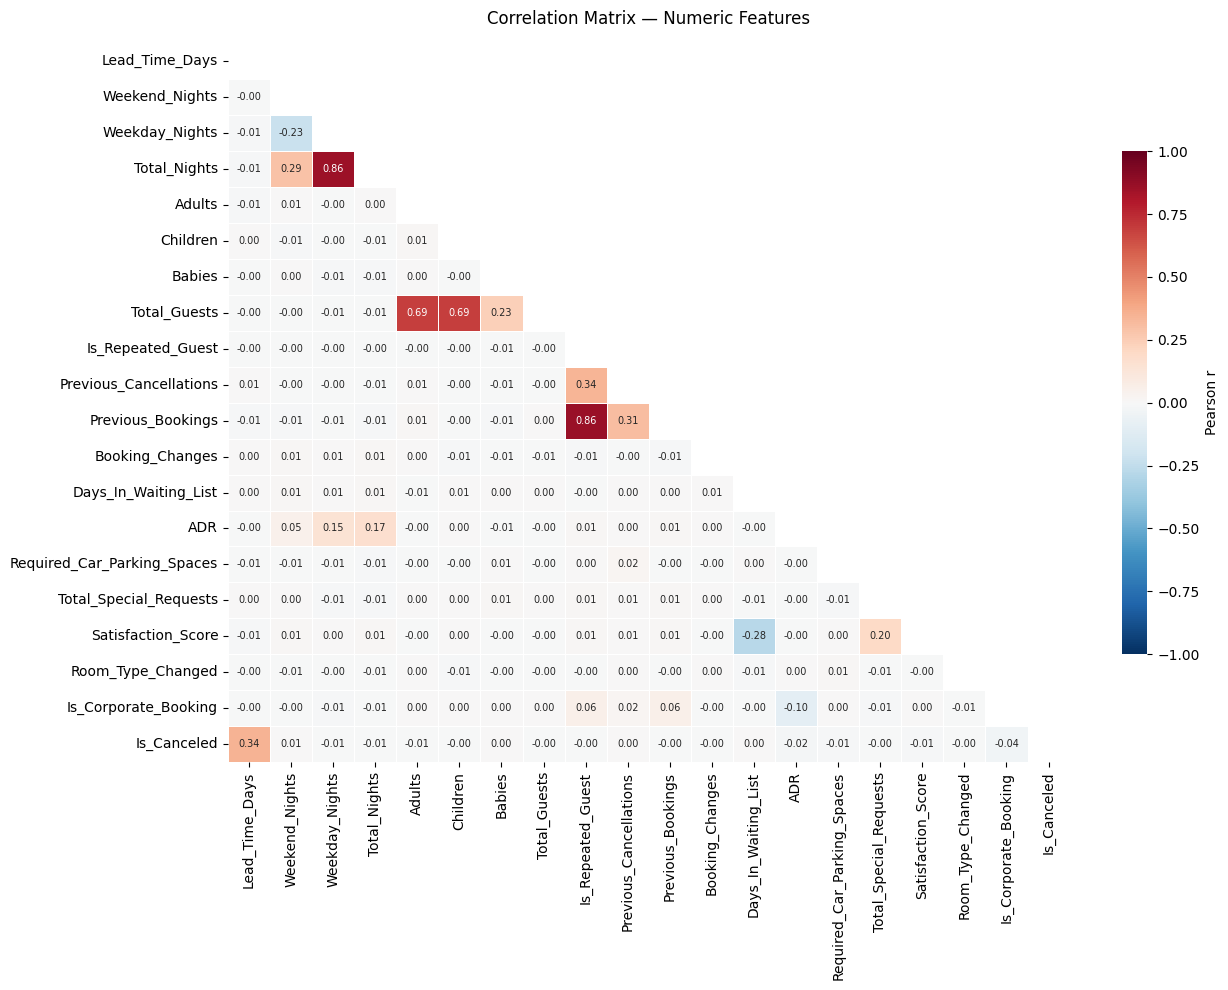

In [49]:
corr_cols = ["Lead_Time_Days", "Weekend_Nights", "Weekday_Nights", "Total_Nights",
             "Adults", "Children", "Babies", "Total_Guests", "Is_Repeated_Guest",
             "Previous_Cancellations", "Previous_Bookings", "Booking_Changes",
             "Days_In_Waiting_List", "ADR", "Required_Car_Parking_Spaces",
             "Total_Special_Requests", "Satisfaction_Score", "Room_Type_Changed",
             "Is_Corporate_Booking", "Is_Canceled"]

corr = clean[corr_cols].corr(method="pearson")

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, linewidths=0.5, annot_kws={"size": 7},
            cbar_kws={"shrink": 0.7, "label": "Pearson r"}, ax=ax)
ax.set_title("Correlation Matrix — Numeric Features", pad=14)
plt.tight_layout()
plt.show()

In [51]:
print("INSIGHT 1")
print(f"  Cancellation rate           : {clean['Is_Canceled'].mean():.1%}")
print(f"  Revenue realisation rate    : {realised/total_booked:.1%}")
print()
print("INSIGHT 2")
print(clean.groupby('Lead_Time_Band', observed=True)['Is_Canceled']
          .mean().mul(100).round(1).to_string())
print()
print("INSIGHT 3")
print(clean.groupby('Deposit_Type')['Is_Canceled'].agg(['mean', 'size'])
          .assign(mean=lambda d: (d['mean']*100).round(1)).to_string())
print()
print("INSIGHT 4")
print(f"  Peak ADR    : {clean.loc[clean.Season=='Peak','ADR'].mean():.2f}")
print(f"  Off-peak ADR: {clean.loc[clean.Season=='Off-Peak','ADR'].mean():.2f}")
print()

print()
print(f"Room reassignment rate: {clean['Room_Type_Changed'].mean():.1%}")

INSIGHT 1
  Cancellation rate           : 72.2%
  Revenue realisation rate    : 28.2%

INSIGHT 2
Lead_Time_Band
0-30 d       45.1
31-90 d      52.4
91-180 d     66.9
181-365 d    85.8
365+ d       50.0

INSIGHT 3
              mean   size
Deposit_Type             
No Deposit    51.6  12144
Non Refund    93.0  12401
Refundable    54.7    455

INSIGHT 4
  Peak ADR    : 159.94
  Off-peak ADR: 130.75


Room reassignment rate: 11.9%
